## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [4]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.utils.visualization.color_palette import set_color_palette
import skrom.problem_classes.masterclass as master
from skrom.utils.visualization.generate_vtk import generate_vtk
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

### Plot Properties

In [5]:
import sci_mplstyle_package
set_color_palette();

## Full Order Simulation

In [6]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

In [7]:
# Conditional execution block for simulation data generation
if generate_data:
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()

    sim.run_simulation()

Snap 1/64 params=[4.48650825 0.31301699]
Snap 2/64 params=[9.28299845 0.26065637]
Snap 3/64 params=[6.68151046 0.35410424]
Snap 4/64 params=[3.60373116 0.21897709]
Snap 5/64 params=[2.20340966 0.39638575]
Snap 6/64 params=[7.00360106 0.22994737]
Snap 7/64 params=[8.90207015 0.33649338]
Snap 8/64 params=[5.82066786 0.29041957]
Snap 9/64 params=[5.45647599 0.37285122]
Snap 10/64 params=[8.2505305  0.20016302]
Snap 11/64 params=[7.64903512 0.30690435]
Snap 12/64 params=[2.57370676 0.26708034]
Snap 13/64 params=[3.23539672 0.34280134]
Snap 14/64 params=[6.03411373 0.28419091]
Snap 15/64 params=[9.93259069 0.37744346]
Snap 16/64 params=[4.85264752 0.24856612]
Snap 17/64 params=[4.71908837 0.38508647]
Snap 18/64 params=[9.55052881 0.23897604]
Snap 19/64 params=[6.41764228 0.34453328]
Snap 20/64 params=[3.36748903 0.27815594]
Snap 21/64 params=[2.93968612 0.30556607]
Snap 22/64 params=[7.76742727 0.2703779 ]
Snap 23/64 params=[8.13458175 0.36481452]
Snap 24/64 params=[5.08805341 0.21249053]
S

### Load Simulation data

In [8]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\linear\problem_1\ROM_data


### Generate Training Solution Dataset

In [ ]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = rom_data.param_list

# Load solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Mean Subtraction

In [10]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

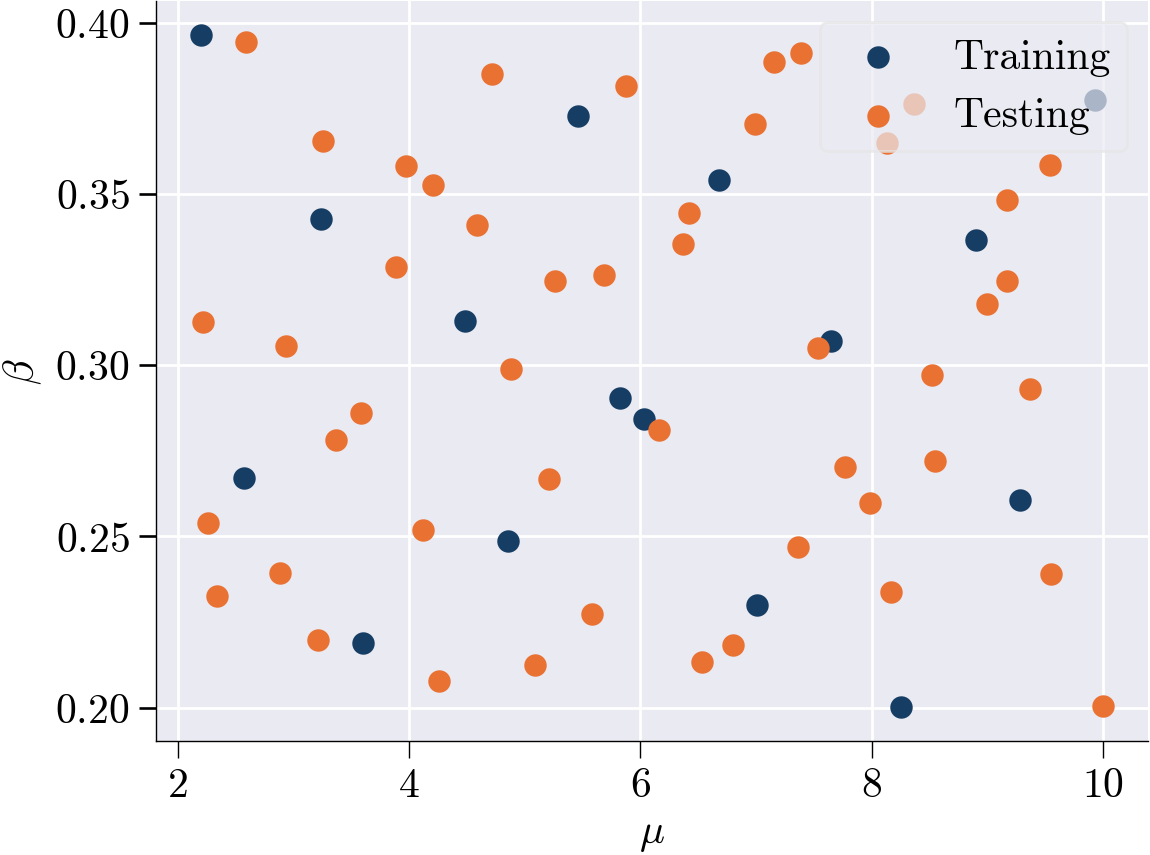

In [11]:
if visualize:
    # Visualize the parameter space distribution for training and testing data
    # Plot training parameter combinations (first 16 samples)
    # Extract first and second parameter columns for 2D visualization
    plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
            param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
            s=50,                      # Marker size
            c='#163e64',              # Dark blue color for training points
            label="Training")         # Legend label

    # Plot testing parameter combinations (samples 17 and beyond)
    plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
            param_list[16:][:, 1],     # Second parameter (β) for testing samples
            s=50,                      # Marker size (same as training)
            c='#e97132',              # Orange color for testing points
            label="Testing")          # Legend label

    # Set axis labels using LaTeX formatting for mathematical notation
    plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
    plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

    # Add legend to distinguish between training and testing sets
    plt.legend()

    #See params and properties to see how these are used

### Performing SVD on solution snapshots

Number of modes selected: 4


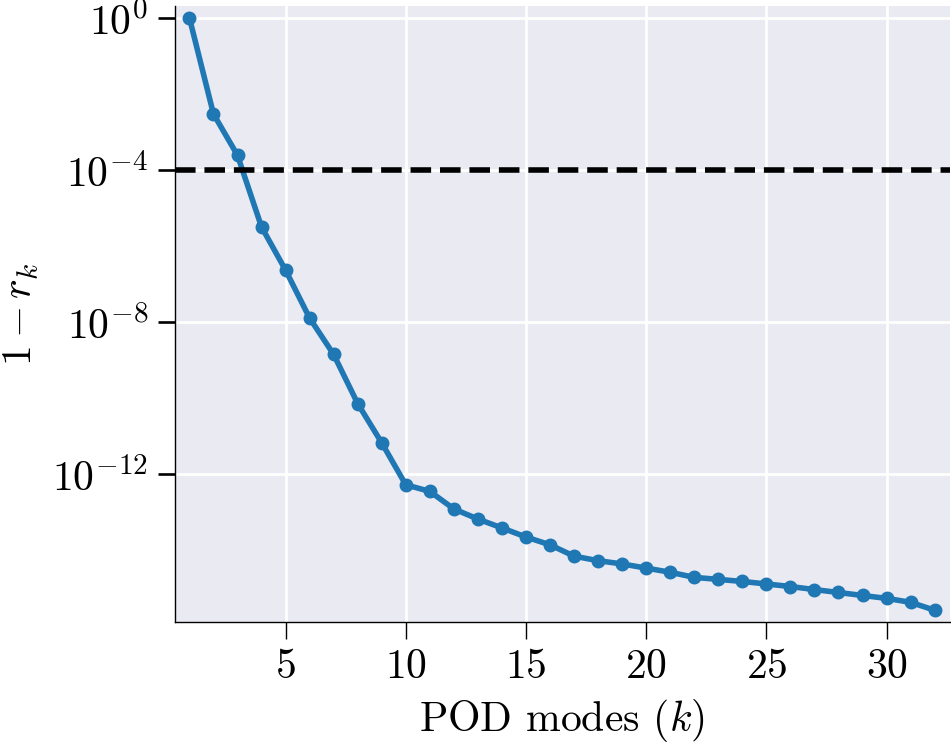

In [12]:
if run_svd:

    # fig, ax = plt.subplots(figsize=(5,3.5))
    plt.rcParams['lines.markersize'] = 6
    plt.rcParams['lines.linewidth'] = 2.0

    n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-4, modes=True)
    V_sel = U[:, :n_sel]
    plt.ylabel('$1-r_{k}$')
    plt.xlabel('POD modes ($k$)')

## ROM Simulation

In [13]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\linear\problem_1\ROM_data


In [14]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/32 params=[6.36696125 0.33544992]
Snap 2/32 params=[3.58789918 0.28595228]
Snap 3/32 params=[5.876158   0.38140613]
Snap 4/32 params=[8.16885803 0.23386168]
Snap 5/32 params=[9.53917761 0.35832911]
Snap 6/32 params=[4.25570922 0.20765889]
Snap 7/32 params=[2.21773168 0.31248278]
Snap 8/32 params=[7.98750119 0.25985939]
Snap 9/32 params=[7.15717691 0.3883871 ]
Snap 10/32 params=[2.88789538 0.23927705]
Snap 11/32 params=[4.58408303 0.34097209]
Snap 12/32 params=[9.37096909 0.29303396]
Snap 13/32 params=[8.99917748 0.3179073 ]
Snap 14/32 params=[5.20598958 0.26684341]
Snap 15/32 params=[3.2595339  0.36540774]
Snap 16/32 params=[6.53517842 0.21317191]
Snap 17/32 params=[6.98632674 0.37035612]
Snap 18/32 params=[3.21506187 0.21985676]
Snap 19/32 params=[5.25691419 0.32450362]
Snap 20/32 params=[8.54181691 0.27205117]
Snap 21/32 params=[9.17006395 0.34826424]
Snap 22/32 params=[4.87879825 0.29893755]
Snap 23/32 params=[2.58672377 0.39420217]
Snap 24/32 params=[7.36429048 0.24682856]
S

In [15]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

ROM Accuracy Report

Global Errors:
L2 Error:                 5.4849e-06
Relative L2 Error:        8.1322e-07
L∞ Error:                 1.8562e-06
Relative L∞ Error:        7.1958e-07
RMSE:                     2.2116e-07
MAE:                      7.9959e-08

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -4.1828e-16
95th Percentile Error:    4.4074e-07

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.4147e-08
Max Rel L2 Error over time/parameter: 8.5766e-08
Min Rel L2 Error over time/parameter: 2.2715e-09
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

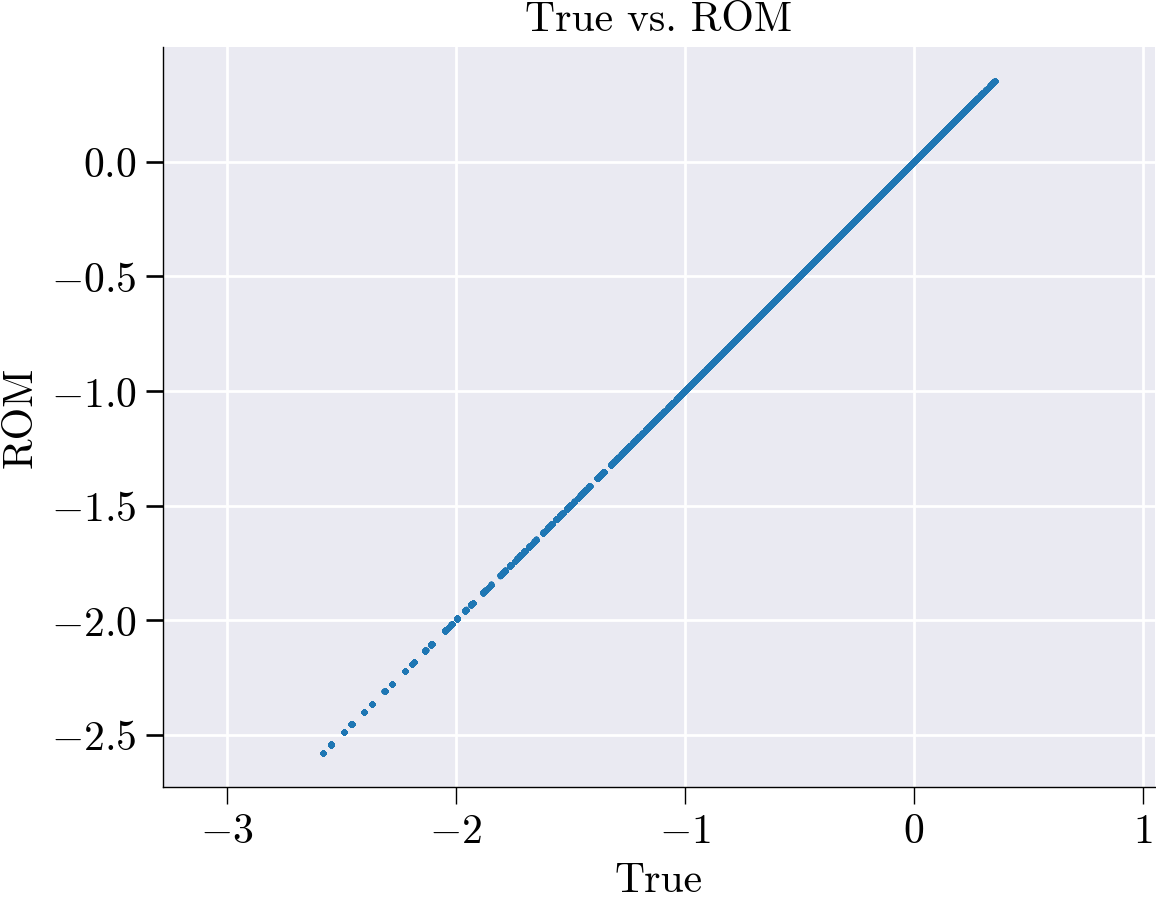

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


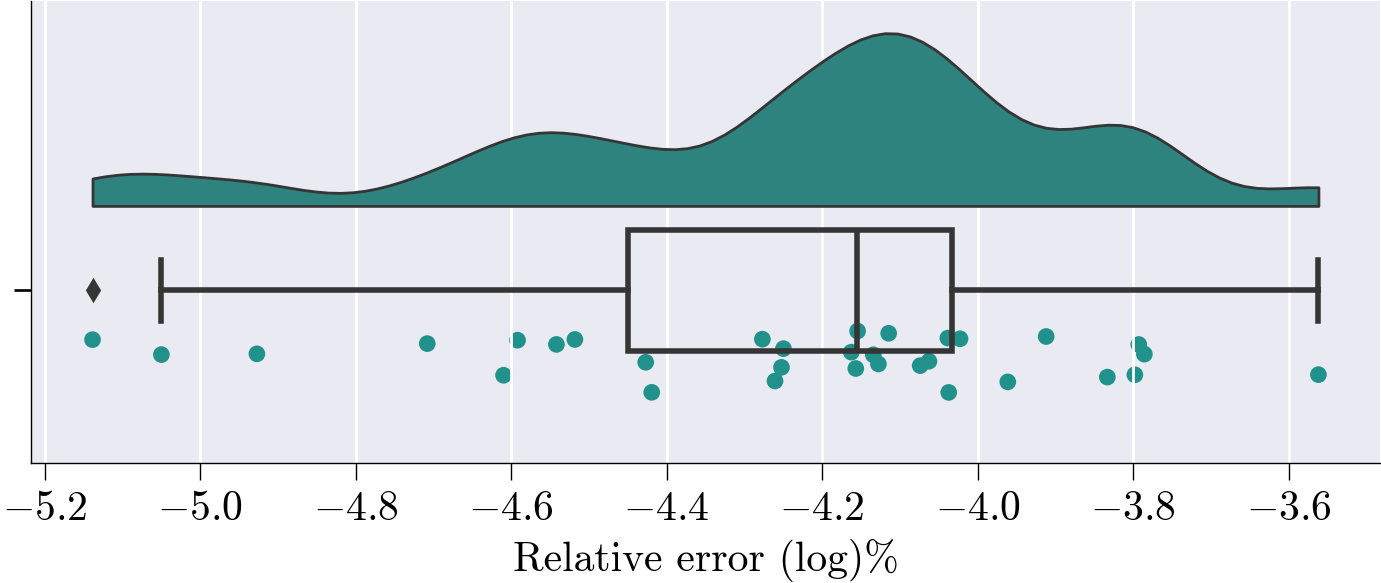

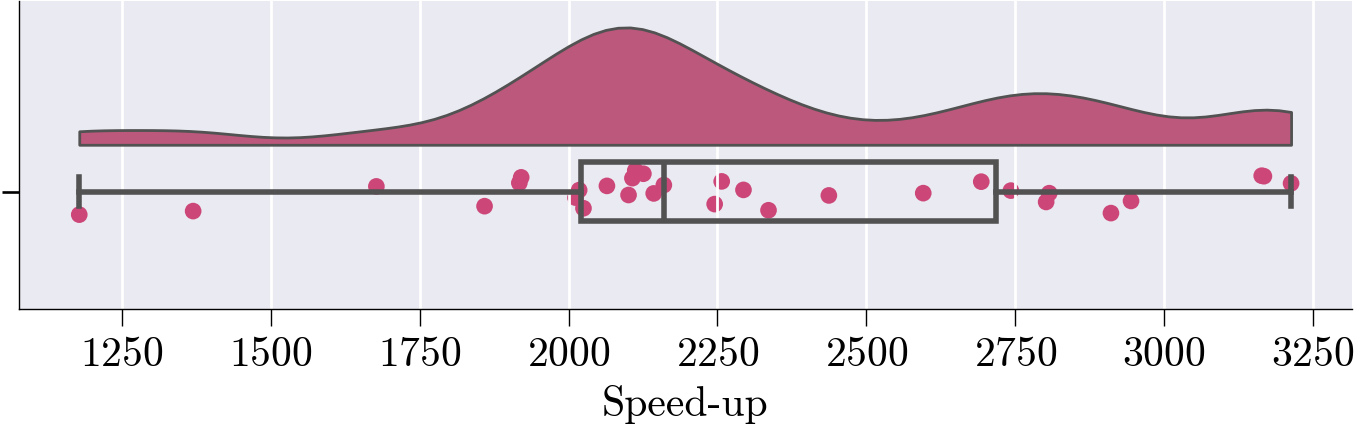

In [16]:
if rom_report:
    # --- ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test,                   # full-order (true) solution snapshots
        LS_rom,              # hyper-ROM-generated solution snapshots
        ROM_relative_error,   # precomputed relative error of the hyper-ROM
        ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )

## Visualize on paraview 

In [17]:
generate_vtk(
    LS_test,
    LS_rom,
    rom_data.mesh,
    rom_data.basis,
    scale = 1.0,
    num_test = 1,
    out_dir = "sol_vtk_files",
)